# 07 — Topography

GRAND is built to see showers arriving within a few degrees of the horizon.
For those, the ground is not a flat plane a long way below the antennas — it is
in the way. A ray at 89° zenith would travel eighty kilometres to drop one
kilometre over flat ground, so whether it clears a ridge is decided by terrain
tens of kilometres from the array.

`grand.geo.topography` is the module for this. It wraps
[TURTLE](https://niess.github.io/turtle-pages/), which reads SRTM elevation
tiles and does ray–ground intersection on the real Earth, and it supplies the
geoid undulation needed to convert between the two height conventions GRAND
data uses.

This notebook works with whatever elevation data is on your machine and says
clearly what it could not do.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

from grand.geo import topography
from grand.geo.coordinates import Geodetic, CartesianRepresentation

print("elevation model :", topography.model())
print("data directory  :", topography.datadir())

# SRTM tiles are named by the south-west corner of the one-degree square they
# cover, e.g. N41E096.hgt spans 41-42 N, 96-97 E.
datadir = str(topography.datadir())
tiles = sorted(f for f in os.listdir(datadir)
               if f.endswith('.hgt')) if os.path.isdir(datadir) else []
HAVE_TILES = len(tiles) > 0
print("tiles present   :", tiles if tiles else "none")

elevation model : SRTMGL1
data directory  : /home/mbustamante/Research/GRAND/GRANDlib/data/topography
tiles present   : ['N41E096.hgt']


The SRTM tiles are **not** in version control — `data/.gitignore` excludes
them, and they are several megabytes each. `topography.update_data()` downloads
what a given region needs. Everything below that requires a tile is guarded, so
this notebook runs either way; on a machine with no tiles it still covers the
geoid and the two failure modes, which is most of what there is to get wrong.

## 1. Two definitions of "height"

A GRAND detection unit has an altitude, and that number means one of two
different things depending on who wrote it down.

- **Ellipsoidal height** is measured from the WGS-84 reference ellipsoid, a
  smooth mathematical surface. GPS reports this.
- **Height above mean sea level** is measured from the *geoid*, the surface of
  equal gravitational potential that sea level follows. Maps and altimeters
  report this.

The difference between them — the **geoid undulation** — reaches ±100 m
worldwide, far larger than the vertical precision GRAND needs for timing. The
EGM96 undulation map ships with the package, so this works with no downloads.

In [2]:
# Pass a Geodetic rather than latitude=/longitude= keywords.  Section 2 shows
# why: the keyword form does not normalise the longitude and the Geodetic form
# does, so this is the one that works everywhere.
print("geoid undulation, in metres:")
for name, lat, lon in [('GRANDProto300 site (China)', 40.98,  93.95),
                       ('Auger site (Argentina)',    -35.20, -69.32),
                       ('Greenland',                  72.00, -40.00),
                       ('Indian Ocean low',            0.00,  78.00)]:
    u = topography.geoid_undulation(Geodetic(latitude=lat, longitude=lon, height=0.0))
    print("   %-28s %+8.2f" % (name, float(np.ravel(u)[0])))

geoid undulation, in metres:
   GRANDProto300 site (China)      -7.75
   Auger site (Argentina)         -44.37
   Greenland                       -1.24
   Indian Ocean low              -102.77


At the GRANDProto300 site the undulation is about −7.7 m: sea level sits 7.7 m
*below* the ellipsoid there. Confusing the two conventions moves every antenna
by that much, which at 2 GHz sampling is roughly 50 samples of light travel
time.

The spread across these four points — from −103 m to −1 m — is the reason this
cannot be treated as a constant offset for an array that spans any distance.

The rule in GRANDlib: `Geodetic.height` is **ellipsoidal**, and
`topography.elevation(..., reference='sea')` converts.

## 2. Two silent failures worth knowing about

Neither of these raises. Both return `nan`, which then propagates quietly into
whatever geometry you were computing and stays plausible for several steps.

**First: the keyword form does not normalise longitude.** The shipped EGM96
map is indexed over 0–360°, and the `latitude=`/`longitude=` path passes the
value through unchanged, while the `Geodetic` path normalises it.

In [3]:
lat, lon = -35.20, -69.32          # the Auger site, in the western hemisphere

kw   = topography.geoid_undulation(latitude=lat, longitude=lon)
wrap = topography.geoid_undulation(latitude=lat, longitude=lon + 360.0)
geo  = topography.geoid_undulation(Geodetic(latitude=lat, longitude=lon, height=0.0))

print("geoid_undulation(latitude=..., longitude=-69.32) :", kw)
print("geoid_undulation(latitude=..., longitude=290.68) :", wrap)
print("geoid_undulation(Geodetic(longitude=-69.32))     :", float(np.ravel(geo)[0]))

geoid_undulation(latitude=..., longitude=-69.32) : nan
geoid_undulation(latitude=..., longitude=290.68) : -44.37145519261511
geoid_undulation(Geodetic(longitude=-69.32))     : -44.37145519261511


Same point, three calls, two different answers and one `nan`. Prefer the
`Geodetic` form; if you must use the keywords, wrap the longitude into
$[0, 360)$ yourself.

**Second: a point with no elevation tile also returns `nan`.**

In [4]:
far = Geodetic(latitude=40.98, longitude=93.95, height=0.0)   # GP300 site
print("elevation with no tile for this square:", topography.elevation(far))

# It propagates: the sea-level reference subtracts the undulation from a nan.
print("elevation(reference='sea')            :",
      topography.elevation(far, reference='sea'))

elevation with no tile for this square: nan
elevation(reference='sea')            : nan


**Check for `nan` after every elevation lookup**, or verify up front that the
tiles covering your region are present. This is the single most common way a
topography calculation goes wrong in practice, and because nothing raises, it
is usually found several steps later.

In [5]:
if not HAVE_TILES:
    print("No SRTM tiles on this machine, so the rest of this notebook is")
    print("descriptive only.  To fetch what a region needs:")
    print()
    print("    from grand.geo import topography")
    print("    from grand.geo.coordinates import Geodetic")
    print("    topography.update_data(Geodetic(latitude=41.5, longitude=96.5,")
    print("                                    height=0.0), radius=50e3)")
else:
    # Work inside whichever square the available tile covers, parsed from its
    # name, so this notebook is not tied to one particular download.
    name = tiles[0]
    lat0 = float(name[1:3]) * (1 if name[0] == 'N' else -1)
    lon0 = float(name[4:7]) * (1 if name[3] == 'E' else -1)
    CENTRE = Geodetic(latitude=lat0 + 0.5, longitude=lon0 + 0.5, height=0.0)
    print("using tile %s -> working near lat %.2f, lon %.2f"
          % (name, lat0 + 0.5, lon0 + 0.5))
    print("elevation there: %.1f m" % topography.elevation(CENTRE))

using tile N41E096.hgt -> working near lat 41.50, lon 96.50
elevation there: 2112.0 m


## 3. The terrain

An elevation map over the tile. This is the surface every ray has to clear.

elevation over the tile: 1746 to 2522 m, median 2046 m
nan fraction: 0.0%


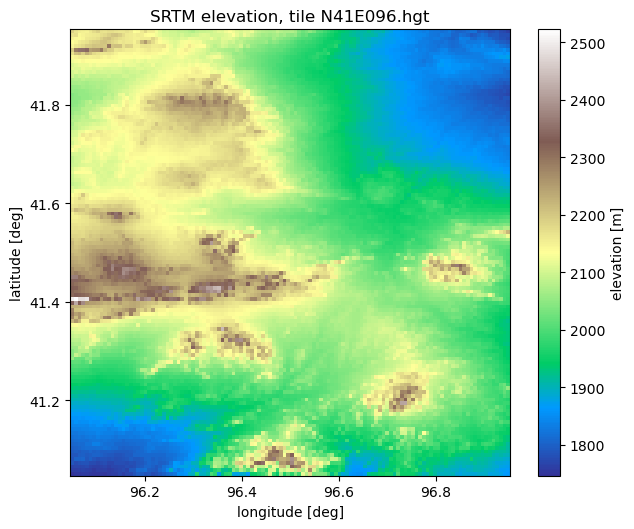

In [6]:
if HAVE_TILES:
    n = 120
    # Stay just inside the tile edges: a query exactly on the boundary may fall
    # into the neighbouring square, which is not downloaded.
    lats = np.linspace(lat0 + 0.05, lat0 + 0.95, n)
    lons = np.linspace(lon0 + 0.05, lon0 + 0.95, n)
    LON, LAT = np.meshgrid(lons, lats)

    # elevation() is vectorised over a Geodetic holding arrays, which is far
    # faster than looping: one TURTLE call instead of n^2.
    grid = topography.elevation(
        Geodetic(latitude=LAT.ravel(), longitude=LON.ravel(),
                 height=np.zeros(LAT.size))).reshape(LAT.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.4))
    pc = ax.pcolormesh(LON, LAT, grid, cmap='terrain', shading='auto')
    fig.colorbar(pc, ax=ax, label='elevation [m]')
    ax.set_xlabel('longitude [deg]')
    ax.set_ylabel('latitude [deg]')
    ax.set_title('SRTM elevation, tile %s' % name)
    fig.tight_layout()

    print("elevation over the tile: %.0f to %.0f m, median %.0f m"
          % (np.nanmin(grid), np.nanmax(grid), np.nanmedian(grid)))
    print("nan fraction: %.1f%%" % (100 * np.isnan(grid).mean()))
else:
    print("skipped: no tiles")

## 4. Where does a very inclined ray meet the ground?

This is what `topography.distance` answers: given a starting point and a
direction, how far to the terrain? It marches along the ray and intersects the
actual elevation model, not a plane.

The direction is a Cartesian vector in the local ENU frame — x east, y north,
z up — so a zenith angle $\theta$ and azimuth $\phi$ become

$$\hat{d} = (\sin\theta\cos\phi,\; \sin\theta\sin\phi,\; -\cos\theta)$$

with the minus sign on $z$ because we are looking downward, towards the
ground.

In [7]:
if HAVE_TILES:
    ground = topography.elevation(CENTRE)
    origin = Geodetic(latitude=lat0 + 0.5, longitude=lon0 + 0.5,
                      height=ground + 1500.0)     # 1.5 km above the terrain

    print("zenith    to ground [km]    flat-ground estimate [km]")
    for zen in (10.0, 45.0, 80.0, 85.0, 88.0, 89.0):
        th, ph = np.radians(zen), 0.0
        d = CartesianRepresentation(x=np.sin(th) * np.cos(ph),
                                    y=np.sin(th) * np.sin(ph),
                                    z=-np.cos(th))
        # maximum_distance bounds the march; without it a ray that never meets
        # the ground searches a long way before giving up.
        dist = float(np.ravel(topography.distance(origin, d,
                                                  maximum_distance=600e3))[0])
        # What a flat plane 1500 m below would have given, for comparison.
        flat = 1500.0 / np.cos(th)
        print("  %5.1f    %14s    %18.2f"
              % (zen, "%.2f" % (dist / 1e3) if np.isfinite(dist) else "not reached",
                 flat / 1e3))
else:
    print("skipped: no tiles")

zenith    to ground [km]    flat-ground estimate [km]
   10.0              2.25                  1.52
   45.0              2.83                  2.12
   80.0              7.44                  8.64
   85.0              9.48                 17.21
   88.0             12.92                 42.98
   89.0             14.74                 85.95


The two columns diverge, and they diverge in *both* directions.

At steep angles the real distance is **longer** than the flat-ground estimate —
2.25 km against 1.52 km at 10° zenith — because the ground falls away below the
launch point. The tile spans 1746 m to 2522 m and the centre sits at 2112 m, so
a ray heading almost straight down has further to fall than the local surface
suggests.

Near the horizon the sign flips and the size grows. At 89° the flat-ground
formula gives 86 km, while the real terrain stops the ray at 15 km: the ground
rises into it. **A flat-ground calculation overestimates the path by a factor
of nearly six there**, and puts the intersection point seventy kilometres
wrong — which for an array a few kilometres across is the difference between a
shower landing inside it and outside it.

Neither error is a small correction to be applied afterwards. Which way it goes
depends on the terrain and on the arrival direction, so there is no single
factor to fold in.

## 5. A profile along a shower axis

Following the terrain along the ray gives the profile that decides whether a
shower is visible from a given antenna.

ray meets the terrain at 32.4 km
profile leaves the tile after 48.4 km


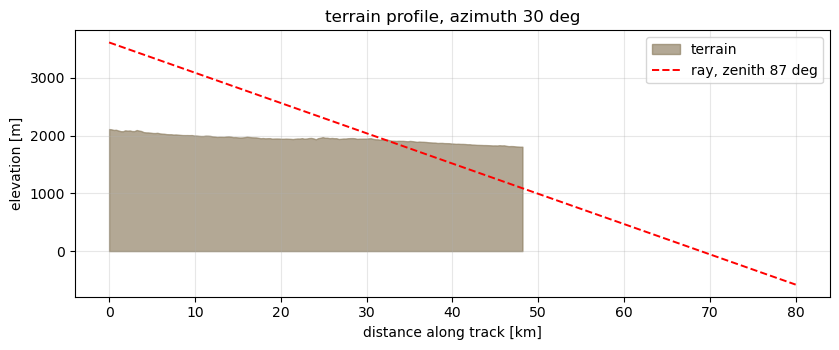

In [8]:
if HAVE_TILES:
    zen, az = 87.0, 30.0
    th, ph = np.radians(zen), np.radians(az)
    east, north = np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph)

    s = np.linspace(0, 80e3, 300)          # along-track distance, metres

    # Small-angle conversion from metres to degrees.  Fine over 80 km; for
    # anything larger, or nearer the poles, use a proper geodesic.
    m_per_deg_lat = 111320.0
    m_per_deg_lon = 111320.0 * np.cos(np.radians(lat0 + 0.5))
    prof_lat = (lat0 + 0.5) + (s * north) / m_per_deg_lat
    prof_lon = (lon0 + 0.5) + (s * east) / m_per_deg_lon

    # Only query inside the tile; outside it every lookup would be nan anyway.
    inside = ((prof_lat > lat0) & (prof_lat < lat0 + 1)
              & (prof_lon > lon0) & (prof_lon < lon0 + 1))
    prof = np.full(s.shape, np.nan)
    prof[inside] = topography.elevation(
        Geodetic(latitude=prof_lat[inside], longitude=prof_lon[inside],
                 height=np.zeros(inside.sum())))

    # The ray, descending at cot(theta) metres per metre of ground track.
    ray = topography.elevation(CENTRE) + 1500.0 - s / np.tan(th)

    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    ax.fill_between(s / 1e3, prof, color='#8a7a5c', alpha=.65, label='terrain')
    ax.plot(s / 1e3, ray, 'r--', lw=1.4, label='ray, zenith %.0f deg' % zen)
    ax.set_xlabel('distance along track [km]')
    ax.set_ylabel('elevation [m]')
    ax.set_title('terrain profile, azimuth %.0f deg' % az)
    ax.grid(alpha=.3)
    ax.legend()
    fig.tight_layout()

    hit = np.where(np.isfinite(prof) & (ray < prof))[0]
    print("ray meets the terrain at %.1f km" % (s[hit[0]] / 1e3) if hit.size
          else "ray stays above the terrain over the whole 80 km")
    print("profile leaves the tile after %.1f km" % (s[~inside][0] / 1e3)
          if (~inside).any() else "profile stays inside the tile")
else:
    print("skipped: no tiles")

## 6. Where topography enters the rest of GRANDlib

Three places, and it is worth knowing which is which.

**Detection-unit altitudes.** `TRun.du_xyz` holds positions in the site frame;
turning them into real altitudes needs the terrain, and getting the geoid
convention wrong shifts every one of them together — a systematic that survives
averaging.

**Shower-axis geometry.** Where the axis meets the ground sets the core
position, and section 4 showed that for inclined showers a flat-ground estimate
gets that badly wrong.

**Antenna orientation.** Detection units are levelled to the local vertical,
which on sloping ground is not the same as the site vertical. The effective
length of notebook 03 is tabulated in the antenna frame, so a slope rotates the
response pattern.

Only the first is currently wired through the simulation chain. The other two
are available through this module but are the caller's responsibility.

## Where next

- [01 — Coordinate systems](01_coordinates.ipynb) — the frames the positions above live in
- [06 — From electric field to ADC counts](06_efield_to_adc.ipynb) — the chain that uses them
- The [API reference](https://grand-mother.github.io/grand-docs/api.html) for `grand.geo.topography`